# Классификация ботов
Тестовое в Avito Data Science Bootcamp 2026

Выполнил Михаил Теребов (mishater888@gmail.com)



**Резюме**

Я изучил структуру данных и выявил потенциальные признаки, отличающие ботов от людей, такие как специфичные интервалы между действиями и технические особенности окружения. Я построил ряд признаков, охватывающий поведение в сессиях, временные паттерны, характеристики браузеров и активность курсора мыши. Валидацию моделей я выстроил по временным окнам, чтобы исключить утечку данных и честно оценить качество. В качестве финального решения я применил ансамбль моделей градиентного бустинга, настроенный с учетом сильного дисбаланса классов в выборке

## Разведка
Для начала просто хочу познакомиться с данными, понять структуру и тд)


In [2]:
import numpy as np
import pandas as pd

train = pd.read_csv('train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('events.csv.gz', parse_dates=['event_ts'])
print(train.shape, test.shape, events.shape)

(11091, 5) (4909, 4) (328905, 14)


In [3]:
print('доля ботов в train:', train.target.mean().round(4))
train.head()

доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [4]:
test.head(1)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21


In [5]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [6]:
print(events.event_name.value_counts(), '\n')
print(events.platform.value_counts(), '\n')
print('Пропуски по колонкам:')
print(events.isna().mean().round(3))

event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64 

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64 

Пропуски по колонкам:
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64


Выделим нужное окно

In [7]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

events_train = events_in_window(events, train)
events_train = events_train.merge(train[['cookie_id', 'target']], on='cookie_id', how='left')
events_test = events_in_window(events, test)
print(len(events_train), len(events_test))

198436 89690


Тяжело на интуитивном уровне работать, так что для пущего понимания посмотрю на логи бота и человека

In [8]:
bot_cookie = train[train['target'] == 1]['cookie_id'].iloc[1]
human_cookie = train[train['target'] == 0]['cookie_id'].iloc[1]

In [9]:
bot_history = events_train[events_train['cookie_id'] == bot_cookie].sort_values('event_ts')
bot_history[['event_ts', 'event_name', 'item_id', 'search_query', 'pointer_x', 'pointer_y']].head(10)

,event_ts,event_name,item_id,search_query,pointer_x,pointer_y
125611,2026-04-06 13:17:05,item_view,1055299.0,NaN,97.0,735.0
77243,2026-04-06 13:17:17,item_view,1038387.0,NaN,311.0,308.0
121180,2026-04-06 13:17:25,search_results_view,NaN,вакансия оператор,281.0,640.0
121678,2026-04-06 13:17:53,item_view,1037805.0,NaN,274.0,289.0
176487,2026-04-06 13:18:38,item_view,1008376.0,NaN,0.0,187.0
166288,2026-04-06 15:31:50,search_results_view,NaN,подработка,383.0,314.0
4266,2026-04-06 15:32:09,item_view,1027002.0,NaN,251.0,341.0
45127,2026-04-06 15:32:34,photo_swipe,1008474.0,NaN,272.0,536.0
122310,2026-04-06 15:33:08,search_results_view,NaN,вакансия продавец,365.0,124.0
36419,2026-04-06 15:33:30,search_results_view,NaN,работа водителем,194.0,360.0


In [10]:
human_history = events_train[events_train['cookie_id'] == human_cookie].sort_values('event_ts')
human_history[['event_ts', 'event_name', 'item_id', 'search_query', 'pointer_x', 'pointer_y']].head(10)

,event_ts,event_name,item_id,search_query,pointer_x,pointer_y
115144,2026-04-06 10:50:26,photo_swipe,1042434.0,NaN,272.0,199.0
103369,2026-04-06 10:52:12,item_view,1012113.0,NaN,845.0,221.0
56221,2026-04-06 10:53:13,item_view,1012113.0,NaN,1305.0,694.0
194534,2026-04-06 10:53:19,contact_phone_show,1020676.0,NaN,1690.0,439.0
158823,2026-04-06 10:54:07,item_view,1011414.0,NaN,757.0,557.0
197625,2026-04-06 10:55:24,item_view,1000931.0,NaN,103.0,654.0
179423,2026-04-06 10:56:20,item_view,1045765.0,NaN,440.0,409.0
101621,2026-04-06 10:56:28,item_view,1042434.0,NaN,637.0,759.0
51515,2026-04-06 10:56:30,search_results_view,NaN,снять квартиру у метро,803.0,789.0
119959,2026-04-06 10:57:19,seller_page_view,1059407.0,NaN,2.0,1046.0


In [11]:
print(events_train.groupby('cookie_id')['event_ts'].is_monotonic_increasing.all()) #отсортированы ли события по рвемени

False


In [12]:
duplicates = events_train.duplicated(subset=['cookie_id', 'event_ts', 'event_name']).sum()
print(f"Количество полных дубликатов по времени и типу события: {duplicates}")

Количество полных дубликатов по времени и типу события: 3202


Посмотрим на user-agent

In [13]:
print("Топ 10 UA для БОТОВ:")
events_train[events_train['target'] == 1]['user_agent'].value_counts().head(10)

Топ 10 UA для БОТОВ:


,count
user_agent,
"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/118.0.0.0 Safari/537.36",1217
"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/114.0.0.0 Safari/537.36",1040
"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/120.0.0.0 Safari/537.36",804
"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",678
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Safari/537.36",591
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 YaBrowser/23.8.0.0 Safari/537.36",561
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:116.0) Gecko/20100101 Firefox/116.0,512
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:110.0) Gecko/20100101 Firefox/110.0,497
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",476


Видно много Headless. Хороший маркер бота, ведь кто из людей пользуется браузером без граф интерфейса

In [14]:
print("Топ 10 UA для ЛЮДЕЙ:")
events_train[events_train['target'] == 0]['user_agent'].value_counts().head(10)

Топ 10 UA для ЛЮДЕЙ:


,count
user_agent,
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Safari/537.36",2154
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 YaBrowser/23.1.0.0 Safari/537.36",1910
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36",1899
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",1885
"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",1874
"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",1858
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:121.0) Gecko/20100101 Firefox/121.0,1842
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 YaBrowser/23.9.0.0 Safari/537.36",1825
"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/113.0.0.0 YaBrowser/23.5.0.0 Safari/537.36",1825


Тут сложно сказать - выглядит просто как адекватный набор)

Посмотрим еще на время

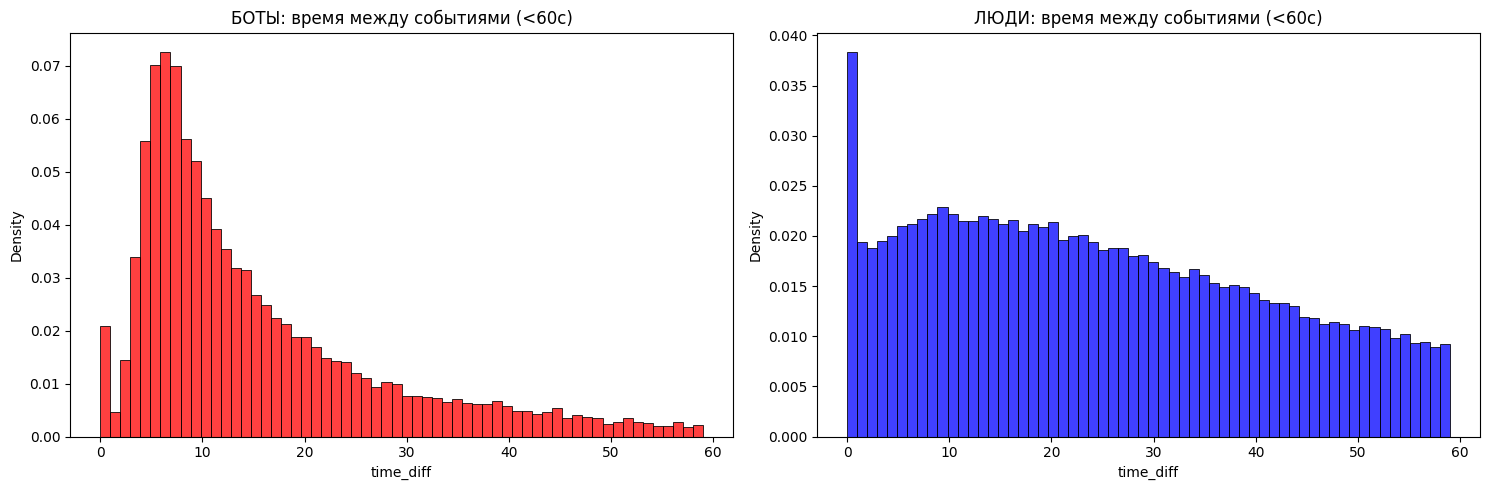

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

events_train = events_train.sort_values(['cookie_id', 'event_ts']) #сортирую по времени, чтобы считать разницу

events_train['time_diff'] = events_train.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()


fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=events_train[(events_train['target'] == 1) & (events_train['time_diff'] < 60)],
             x='time_diff', bins=60, color='red', stat='density', ax=ax[0])
ax[0].set_title('БОТЫ: время между событиями (<60с)')

sns.histplot(data=events_train[(events_train['target'] == 0) & (events_train['time_diff'] < 60)],
             x='time_diff', bins=60, color='blue', stat='density', ax=ax[1])
ax[1].set_title('ЛЮДИ: время между событиями (<60с)')

plt.tight_layout()
plt.show()

Очень интересно: у людей относительно равномерно распредлены действия, у ботов заметный пик в районе 8 секунд, видимо защита от бана

Посмотрим на координаты мышки

Доля пропусков в координатах:
target
0    0.652624
1    0.754065
Name: pointer_x, dtype: float64


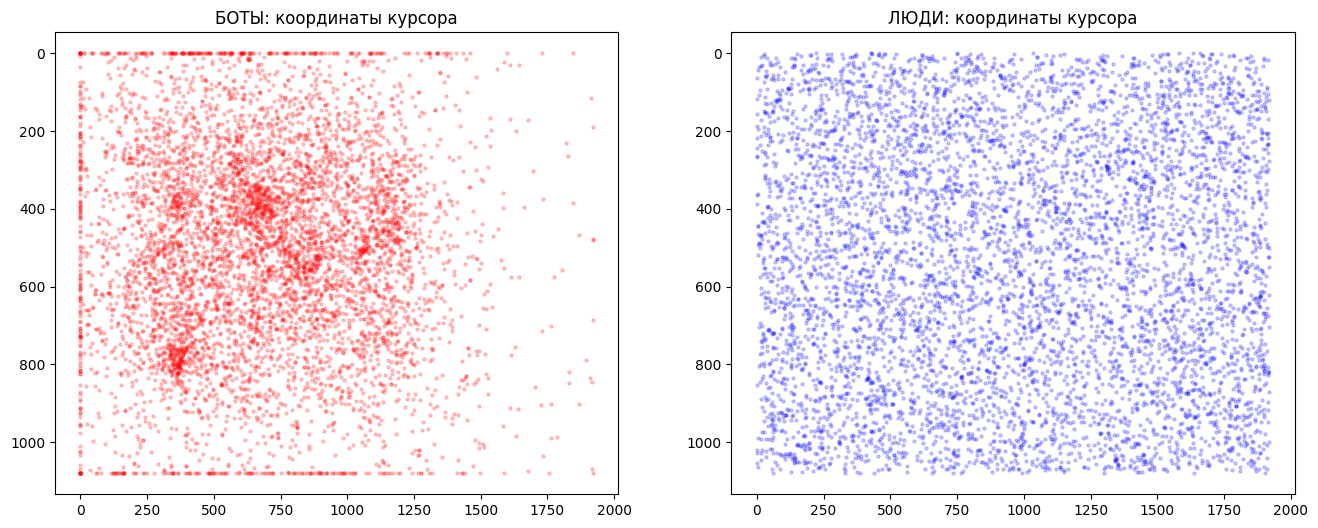

In [16]:
print("Доля пропусков в координатах:")
print(events_train.groupby('target')['pointer_x'].apply(lambda x: x.isna().mean()))

#только события с непустыми координатами:
bots_ptr = events_train[(events_train['target'] == 1) & (events_train['pointer_x'].notna())]
humans_ptr = events_train[(events_train['target'] == 0) & (events_train['pointer_x'].notna())]

# чтобы адекватно сравнить возьмем равное число точек
sample_size = min(len(bots_ptr), len(humans_ptr))
bots_ptr_sample = bots_ptr.sample(n=sample_size, random_state=42)
humans_ptr_sample = humans_ptr.sample(n=sample_size, random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(bots_ptr_sample['pointer_x'], bots_ptr_sample['pointer_y'], alpha=0.2, s=5, c='red')
ax[0].set_title('БОТЫ: координаты курсора')
ax[0].invert_yaxis()

ax[1].scatter(humans_ptr_sample['pointer_x'], humans_ptr_sample['pointer_y'], alpha=0.2, s=5, c='blue')
ax[1].set_title('ЛЮДИ: координаты курсора')
ax[1].invert_yaxis()

plt.show()

Доля пропусков не особо информативна. По графику у ботов есть явные паттерны, хотя их сложно описать как-то осмысленно. Но учтем

Теперь к самим событиям

In [17]:
#посчитаем количество каждого типа события по классам
event_counts = events_train.groupby(['target', 'event_name']).size().unstack(fill_value=0)

event_props = event_counts.div(event_counts.sum(axis=1), axis=0) * 100 #проценты

print("доля каждого события от всех действий класса (%):")
display(event_props.T.round(2))

доля каждого события от всех действий класса (%):


target,0,1
event_name,,
contact_chat_open,1.98,1.42
contact_message_sent,1.03,0.79
contact_phone_show,3.70,2.58
favorite_add,6.58,2.72
item_view,36.51,43.64
login,2.15,0.78
photo_swipe,12.27,7.02
search_results_view,30.48,35.15
seller_page_view,5.31,5.90


Есть активности, которые могут вполне указывать на принадлежность к классу. Например, добавление в избранное и пролистывание фоток явно более человеческие активности

Посмотрим на контент

In [18]:
#количество уникальных категорий и городов для каждой куки
entropy_df = events_train.groupby(['cookie_id', 'target']).agg(
    unique_categories=('item_category', 'nunique'),
    unique_locations=('item_location', 'nunique')
).reset_index()

print("Среднее количество уникальных категорий и городов за сессию:")
entropy_df.groupby('target')[['unique_categories', 'unique_locations']].mean().round(2)

Среднее количество уникальных категорий и городов за сессию:


,unique_categories,unique_locations
target,,
0,2.28,5.88
1,1.79,9.79


Боты в среднем рассматривают значительно больше городов и меньше категорий

## Первичная обработка
Из eda уже видно, что можно учесть, пойдем по порядку

1) В platform есть дубликаты, уберем лишний мусор

In [19]:
print("до нормализации:")
print(events_train['platform'].value_counts())

#все к нижнему регистру
events_train['platform'] = events_train['platform'].str.lower()
print()
print("После нормализации:")
print(events_train['platform'].value_counts())

до нормализации:
platform
desktop    27855
Web        27470
WEB        27431
web        27251
ANDROID    26209
Android    25893
android    25889
IOS         2634
iOS         2626
iphone      2602
ios         2576
Name: count, dtype: int64

После нормализации:
platform
web        82152
android    77991
desktop    27855
ios         7836
iphone      2602
Name: count, dtype: int64


iphone и ios явно одно и тоже, такого think different нам не надо

In [20]:
events_train['platform'] = events_train['platform'].replace('iphone', 'ios')
print("После нормализации:")
print(events_train['platform'].value_counts())

После нормализации:
platform
web        82152
android    77991
desktop    27855
ios        10438
Name: count, dtype: int64


Следующее - это время. Хочу убедиться, что все по порядку

In [21]:
events_train = events_train.sort_values(['cookie_id', 'event_ts']).reset_index(drop=True)

#проверко
is_sorted = events_train.groupby('cookie_id')['event_ts'].is_monotonic_increasing.all()
print(f"все упорядочено: {is_sorted}")

все упорядочено: True


У нас есть 3к дублей по кука-время-события. Возможно дубли о чем-то говорят и могут стать значимым признаком, все равно удалим их, но сделаем колонку колво дублей

In [22]:
events_count_before = events_train.groupby('cookie_id').size()

#удаляю дубликаты кука-время-событие
events_train = events_train.drop_duplicates(subset=['cookie_id', 'event_ts', 'event_name']).copy()
events_count_after = events_train.groupby('cookie_id').size()

duplicates_feature = (events_count_before - events_count_after).rename('duplicates_count').reset_index()

print(f"удалено дубликатов: {events_count_before.sum() - events_count_after.sum()}")
duplicates_feature.sort_values('duplicates_count', ascending=False).head()

удалено дубликатов: 3202


,cookie_id,duplicates_count
3400,ck_4d8ef9c58607a08b,6
8334,ck_c0145a60548546fb,6
2297,ck_33efd70908ad1388,5
4815,ck_6f6c5bb9f309b019,5
7032,ck_a1915b0647678fdf,5


Выделим уникальные сессии, порог сделаем 30 мин между действиями

In [23]:
is_new_session = (events_train['time_diff'] > 1800) | (events_train['time_diff'].isna())

#кумсумма флагов = уникальный ID для каждой сессии
events_train['session_id'] = is_new_session.cumsum()

print(f"Всего событий: {len(events_train)}")
print(f"Всего уникальных сессий: {events_train['session_id'].nunique()}")

Всего событий: 195234
Всего уникальных сессий: 32780


Переведем текст в единый вид и разметим пропуски

In [24]:
events_train['item_category'] = events_train['item_category'].str.lower().str.strip()
events_train['item_location'] = events_train['item_location'].str.lower().str.strip()
events_train['user_agent'] = events_train['user_agent'].str.lower().str.strip()
events_train['search_query'] = events_train['search_query'].str.lower().str.strip()

In [25]:
cat_cols = ['item_category', 'item_location', 'seller_type', 'search_query']
events_train[cat_cols] = events_train[cat_cols].fillna('unknown')

num_cols = ['item_id', 'search_page', 'pointer_x', 'pointer_y', 'time_diff']
events_train[num_cols] = events_train[num_cols].fillna(-1)

for col in ['platform', 'event_name', 'item_category', 'item_location', 'seller_type']:
    events_train[col] = events_train[col].astype('category')

## Разработка признаков
ну поехали

In [26]:
X_train = train.copy()
X_test = test.copy()

### Временные признаки

In [27]:
def temporal_features(ev, meta):
    ev = ev.sort_values(['cookie_id', 'event_ts'])

    #время между соседями
    ev['time_diff'] = ev.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()

    # подозрительная задержка в районе 8 сек
    ev['is_8_sec_pattern'] = ev['time_diff'].between(7, 9).astype(int)
    #ночная активность (с 00:00 до 06:00)
    ev['is_night'] = ev['event_ts'].dt.hour.isin([0, 1, 2, 3, 4, 5, 6]).astype(int)

    #сгруппировали по кукам
    g = ev.groupby('cookie_id')
    f = pd.DataFrame()

    #базовые статистики по времени между событиями
    f['time_diff_mean'] = g['time_diff'].mean()
    f['time_diff_median'] = g['time_diff'].median()
    f['time_diff_std'] = g['time_diff'].std().fillna(0) # 0, если было только 1 событие
    f['time_diff_max'] = g['time_diff'].max()

    # продолжительность сессии в секундах
    f['session_duration'] = (g['event_ts'].max() - g['event_ts'].min()).dt.total_seconds()

    # скорость генерации событий (событий в секунду). Добавляем +1, чтобы избежать деления на 0
    f['events_per_second'] = g.size() / (f['session_duration'] + 1)

    # доля событий с типичной "ботовой" задержкой
    f['8_sec_pattern_count'] = g['is_8_sec_pattern'].sum()
    f['8_sec_pattern_ratio'] = f['8_sec_pattern_count'] / g.size()

    # доля ночных событий
    f['night_events_count'] = g['is_night'].sum()
    f['night_events_ratio'] = f['night_events_count'] / g.size()

    #объединю с метой
    f = meta[['cookie_id', 'cookie_created_at']].merge(f.reset_index(), on='cookie_id', how='left')

    #первое событие в окне для каждой куки
    first_ts = g['event_ts'].min().reset_index(name='first_event_ts')
    f = f.merge(first_ts, on='cookie_id', how='left')

    #возраст куки в секундах на момент совершения первого действия в текущем окне
    f['cookie_age_sec'] = (f['first_event_ts'] - f['cookie_created_at']).dt.total_seconds()

    # удаляем сырые временные метки
    f = f.drop(columns=['cookie_created_at', 'first_event_ts'])
    return f.fillna(0)

In [28]:
temporal_train = temporal_features(events_train, train)
temporal_test = temporal_features(events_test, test)

X_train = X_train.merge(temporal_train, on='cookie_id', how='left')
X_test = X_test.merge(temporal_test, on='cookie_id', how='left')

### Поведенческие признаки

In [29]:
def behavioral_features(ev, meta):
    #количество каждого типа события для каждой куки
    event_counts = ev.pivot_table(
        index='cookie_id',
        columns='event_name',
        values='event_ts',
        aggfunc='count',
        fill_value=0
    )

    event_counts.columns = [f'count_{col}' for col in event_counts.columns]

    expected_events = [
        'count_item_view', 'count_search_results_view', 'count_photo_swipe',
        'count_favorite_add', 'count_seller_page_view', 'count_contact_phone_show',
        'count_captcha_shown', 'count_login', 'count_contact_chat_open',
        'count_contact_message_sent'
    ]
    for col in expected_events:
        if col not in event_counts.columns:
            event_counts[col] = 0

    #агрегаты по кукам
    g = ev.groupby('cookie_id')
    f = pd.DataFrame(index=g.groups.keys())

    f['n_events'] = g.size()
    f['item_nunique'] = g['item_id'].nunique()
    f['category_nunique'] = g['item_category'].nunique()
    f['location_nunique'] = g['item_location'].nunique()
    f['search_query_nunique'] = g['search_query'].nunique()

    #максимальная страница выдачи поиска (если пустая, ставим 0)
    f['search_page_max'] = g['search_page'].max().fillna(0)

    f = f.join(event_counts)

    # доля показов капчи
    f['captcha_ratio'] = f['count_captcha_shown'] / f['n_events']

    # конверсия поиск в просмотр объявления
    f['search_to_view_cv'] = f['count_item_view'] / (f['count_search_results_view'] + 1) # +1 чтобы не было на ноль деления

    # конверсия просмотр объявления в показ телефона
    f['view_to_contact_cv'] = f['count_contact_phone_show'] / (f['count_item_view'] + 1)

    #отношение уникальных объявлений к общему числу просмотров объявлений
    f['item_view_diversity'] = f['item_nunique'] / (f['count_item_view'] + 1)

    res = meta[['cookie_id']].merge(f.reset_index(names='cookie_id'), on='cookie_id', how='left')
    return res.fillna(0)

In [30]:
behavioral_train = behavioral_features(events_train, train)
behavioral_test = behavioral_features(events_test, test)

X_train = X_train.merge(behavioral_train, on='cookie_id', how='left')
X_test = X_test.merge(behavioral_test, on='cookie_id', how='left')

/tmp/ipykernel_832/3245961586.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  event_counts = ev.pivot_table(


### Технические (?) признаки

In [31]:
def technical_features(ev, meta):

    ev_tech = ev[['cookie_id', 'platform', 'user_agent']].copy()

    #  флаги на наличие ключевых слов
    ev_tech['is_headless'] = ev_tech['user_agent'].str.contains('headless', na=False).astype(int)
    ev_tech['is_bot'] = ev_tech['user_agent'].str.contains('bot', na=False).astype(int)

    # извлечем версии Firefox (были подозрительными)
    ev_tech['firefox_version'] = ev_tech['user_agent'].str.extract(r'firefox/(\d+)').astype(float)

    # Все, что ниже 120 версии, помечаем как старый
    ev_tech['is_old_firefox'] = ((ev_tech['firefox_version'] > 0) &
                                 (ev_tech['firefox_version'] < 120)).astype(int)

    g = ev_tech.groupby('cookie_id')
    f = pd.DataFrame(index=g.groups.keys())

    f['platform_nunique'] = g['platform'].nunique()
    f['ua_nunique'] = g['user_agent'].nunique()

    f['has_headless_any'] = g['is_headless'].max()
    f['has_bot_any'] = g['is_bot'].max()
    f['is_old_firefox_any'] = g['is_old_firefox'].max()

    #доля событий с Headless Chrome от общего числа событий куки
    f['headless_ratio'] = g['is_headless'].sum() / g.size()

    res = meta[['cookie_id']].merge(f.reset_index(names='cookie_id'), on='cookie_id', how='left')
    return res.fillna(0)

In [32]:
technical_train = technical_features(events_train, train)
technical_test = technical_features(events_test, test)

X_train = X_train.merge(technical_train, on='cookie_id', how='left')
X_test = X_test.merge(technical_test, on='cookie_id', how='left')

### Признаки курсора

In [33]:
def cursor_features(ev, meta):

    ev_curs = ev[['cookie_id', 'event_ts', 'pointer_x', 'pointer_y']].copy()
    ev_curs['has_pointer'] = ev_curs['pointer_x'].notna().astype(int)

    #доля событий с непустыми координатами для каждой куки
    g_all = ev_curs.groupby('cookie_id')
    f = pd.DataFrame(index=g_all.groups.keys())
    f['pointer_present_ratio'] = g_all['has_pointer'].mean()

    # оставим только события, где координаты есть, и сортируем по времени
    ev_ptr = ev_curs.dropna(subset=['pointer_x', 'pointer_y']).sort_values(['cookie_id', 'event_ts'])
    if len(ev_ptr) > 0:
        # дельты координат между последовательными действиями
        ev_ptr['prev_x'] = ev_ptr.groupby('cookie_id')['pointer_x'].shift(1)
        ev_ptr['prev_y'] = ev_ptr.groupby('cookie_id')['pointer_y'].shift(1)

        ev_ptr['cursor_distance'] = np.sqrt(
            (ev_ptr['pointer_x'] - ev_ptr['prev_x'])**2 +
            (ev_ptr['pointer_y'] - ev_ptr['prev_y'])**2
        )

        # поиск аномалий
        ev_ptr['is_zero_x'] = (ev_ptr['pointer_x'] == 0).astype(int)
        ev_ptr['is_zero_y'] = (ev_ptr['pointer_y'] == 0).astype(int)

        g_ptr = ev_ptr.groupby('cookie_id')

        sizes = g_ptr.size().replace(0, np.nan)
        f['zero_x_ratio'] = g_ptr['is_zero_x'].sum() / sizes
        f['zero_y_ratio'] = g_ptr['is_zero_y'].sum() / sizes

        # статистики
        f['pointer_x_std'] = g_ptr['pointer_x'].std()
        f['pointer_y_std'] = g_ptr['pointer_y'].std()
        f['cursor_distance_mean'] = g_ptr['cursor_distance'].mean()
        f['cursor_distance_max'] = g_ptr['cursor_distance'].max()
    else:
        f['pointer_x_std'] = 0
        f['pointer_y_std'] = 0
        f['cursor_distance_mean'] = 0
        f['cursor_distance_max'] = 0
        f['zero_x_ratio'] = 0
        f['zero_y_ratio'] = 0

    res = meta[['cookie_id']].merge(f.reset_index(names='cookie_id'), on='cookie_id', how='left')
    return res.fillna(0)

In [34]:
cursor_train = cursor_features(events_train, train)
cursor_test = cursor_features(events_test, test)

X_train = X_train.merge(cursor_train, on='cookie_id', how='left')
X_test = X_test.merge(cursor_test, on='cookie_id', how='left')

## Строю модели

### CatBoost

In [42]:
import optuna
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import log_loss
import warnings

from metric import precision_at_recall

warnings.filterwarnings('ignore')

X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]
drop_cols = ['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts', 'target']
features = [c for c in X_train.columns if c not in drop_cols and X_train[c].dtype != 'object']
is_valid = X_train['window_start_ts'] >= '2026-04-17'

X_tr = X_train.loc[~is_valid, features].astype(float)
y_tr = X_train.loc[~is_valid, 'target'].astype(int)

X_va = X_train.loc[is_valid, features].astype(float)
y_va = X_train.loc[is_valid, 'target'].astype(int)

X_te = X_test[features].astype(float)


#оптимизация CatBoost
def objective_cb(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1.0, 11.0]),
        'random_seed': 0,
        'verbose': False,
        'eval_metric': 'Logloss'
    }

    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], early_stopping_rounds=50)

    preds = model.predict_proba(X_va)[:, 1]
    score = precision_at_recall(y_va.values, preds)
    return score

print("начинаем тюнинг CatBoost")
study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=70)
print(f"Лучший скор CatBoost P@R0.7: {study_cb.best_value:.4f}")

[I 2026-09-28 21:11:13,991] A new study created in memory with name: no-name-264cddc3-3ced-4d4a-93bd-1f73b67ab9d6


начинаем тюнинг CatBoost


[I 2026-09-28 21:11:16,501] Trial 0 finished with value: 0.7671232876712328 and parameters: {'iterations': 250, 'learning_rate': 0.02839172838089928, 'depth': 6, 'l2_leaf_reg': 5.8451138964766045, 'scale_pos_weight': 1.0}. Best is trial 0 with value: 0.7671232876712328.
[I 2026-09-28 21:11:19,910] Trial 1 finished with value: 0.7466666666666667 and parameters: {'iterations': 239, 'learning_rate': 0.017642982465807523, 'depth': 7, 'l2_leaf_reg': 9.744768914451237, 'scale_pos_weight': 1.0}. Best is trial 0 with value: 0.7671232876712328.
[I 2026-09-28 21:11:22,922] Trial 2 finished with value: 0.64 and parameters: {'iterations': 236, 'learning_rate': 0.011273548956798881, 'depth': 6, 'l2_leaf_reg': 7.984474897251316, 'scale_pos_weight': 11.0}. Best is trial 0 with value: 0.7671232876712328.
[I 2026-09-28 21:11:30,874] Trial 3 finished with value: 0.7516778523489933 and parameters: {'iterations': 295, 'learning_rate': 0.021569282634598647, 'depth': 8, 'l2_leaf_reg': 5.177697434212063, 'sc

Лучший скор CatBoost P@R0.7: 0.8235


### LightGBM

In [43]:
import optuna
from lightgbm import LGBMClassifier
import warnings
from metric import precision_at_recall

warnings.filterwarnings('ignore')

X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

drop_cols = ['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts', 'target']
features = [c for c in X_train.columns if c not in drop_cols and X_train[c].dtype != 'object']

is_valid = X_train['window_start_ts'] >= '2026-04-17'

X_tr = X_train.loc[~is_valid, features].astype(float)
y_tr = X_train.loc[~is_valid, 'target'].astype(int)

X_va = X_train.loc[is_valid, features].astype(float)
y_va = X_train.loc[is_valid, 'target'].astype(int)

X_te = X_test[features].astype(float)


def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 120),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1.0, 11.0]),
        'random_state': 0,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMClassifier(**params)

    model.fit(X_tr, y_tr)

    preds = model.predict_proba(X_va)[:, 1]

    score = precision_at_recall(y_va.values, preds)
    return score

print("начинаем тюнинг LightGBM")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=70)
print()
print(f"Лучший скор LightGBM: {study_lgb.best_value:.4f}")
print("Лучшие параметры:", study_lgb.best_params)

[I 2026-09-28 21:20:15,528] A new study created in memory with name: no-name-0ca7538c-0898-4d6e-ad62-8f9d2ba30094


начинаем тюнинг LightGBM


[I 2026-09-28 21:20:17,095] Trial 0 finished with value: 0.7583892617449665 and parameters: {'n_estimators': 433, 'learning_rate': 0.03310660500681231, 'num_leaves': 66, 'max_depth': 3, 'min_child_samples': 15, 'subsample': 0.9938073634610198, 'colsample_bytree': 0.8389167841720628, 'scale_pos_weight': 1.0}. Best is trial 0 with value: 0.7583892617449665.
[I 2026-09-28 21:20:19,814] Trial 1 finished with value: 0.7320261437908496 and parameters: {'n_estimators': 704, 'learning_rate': 0.01244176658846363, 'num_leaves': 64, 'max_depth': 9, 'min_child_samples': 45, 'subsample': 0.6538544366924417, 'colsample_bytree': 0.5170624551717444, 'scale_pos_weight': 11.0}. Best is trial 0 with value: 0.7583892617449665.
[I 2026-09-28 21:20:21,565] Trial 2 finished with value: 0.7671232876712328 and parameters: {'n_estimators': 895, 'learning_rate': 0.06327434231590398, 'num_leaves': 21, 'max_depth': 6, 'min_child_samples': 48, 'subsample': 0.7940461577478954, 'colsample_bytree': 0.5972869204360771,


Лучший скор LightGBM: 0.8235
Лучшие параметры: {'n_estimators': 855, 'learning_rate': 0.025899070963375286, 'num_leaves': 73, 'max_depth': 10, 'min_child_samples': 71, 'subsample': 0.5412724294535829, 'colsample_bytree': 0.9522074996821277, 'scale_pos_weight': 1.0}


### Ансамбль

In [47]:
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

drop_cols = ['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts', 'target']
features = [c for c in X_train.columns if c not in drop_cols and X_train[c].dtype != 'object']

X_tr_full = X_train[features].astype(float)
y_tr_full = X_train['target'].astype(int)
X_te_full = X_test[features].astype(float)


model_cb = CatBoostClassifier(
    **study_cb.best_params,
    random_seed=0,
    verbose=False
)
model_cb.fit(X_tr_full, y_tr_full)

model_lgb = LGBMClassifier(
    **study_lgb.best_params,
    random_state=0,
    n_jobs=-1,
    verbose=-1
)
model_lgb.fit(X_tr_full, y_tr_full)

# ансамбль
preds_cb = model_cb.predict_proba(X_te_full)[:, 1]
preds_lgb = model_lgb.predict_proba(X_te_full)[:, 1]
ensemble_preds = 0.5 * preds_cb + 0.5 * preds_lgb

sub = pd.DataFrame({
    'cookie_id': X_test['cookie_id'],
    'score': ensemble_preds
})

## Генерация сабмита

In [50]:
sub = sub[['cookie_id', 'score']]

sub.to_csv('submission_Mikhail_Terebov.csv', index=False)